In [640]:
from codecs import ignore_errors
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.utils import class_weight
import xgboost as xgb
from sklearn.linear_model import Ridge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.impute import SimpleImputer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import keras_tuner as kt
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score,mean_absolute_error,classification_report,confusion_matrix
from xgboost import XGBModel,XGBRanker, XGBRegressor
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt 
import seaborn as sns 
ignore_errors


<function ignore_errors>

### Water Quality Dataset is more than 750mb so i processed  all format and need column 

In [641]:
from fileChangeWQ import process_file_water

### Cleaning the dataset 
#### The flood,climate and water quality datasets were set in class and cleaned 
#### Each datasets where with  match and case according to process key(The data type of the dictionary key is STRING) 

In [642]:
class cleanData():
    #constructor
    def __init__(self,raw_data):
        self.raw_data=raw_data
    def clean_all(self,process_flags,):
        """_summary_

        Args:print(f"Shape of the water quality data before cleaning{water_data.shape}")
            process_flags (str): matching the dataset to  according to the processes key

        Returns:
            dataFrame: returns the clean and formatted data. 
        """
        data=self.raw_data
        match(process_flags):
            #cleaning water data 
            case 'water':
                data['only_date']=pd.to_datetime(data['only_date']).dt.normalize()
                data['location']=data['sample.samplingPoint.notation'].str.split("-").str[0]
                data.drop(columns=['Unnamed: 0','sample.samplingPoint.label','sample.samplingPoint.northing','sample.samplingPoint.easting'],inplace=True)
                data.fillna(0)
                print("Water Quality Dataset got glow up !")
                return data
            case 'flood':
                #clean ing the historical flood data 
                data.drop(columns=['Unnamed: 0'],inplace=True)
                data.columns=data.columns.str.strip()
                data['only_date']=pd.to_datetime(data['DATE'],errors='coerce').dt.normalize()
                #BRITISH GRID for Location mapping and classifiction
                def no_cap_map_grid(area):
                    area = str(area).upper()
                    if 'NW' in area or 'CUMBRIA' in area or 'LANCASHIRE' in area or 'MANCS' in area: return 'NW'
                    if 'SW' in area or 'DEVON' in area or 'WESSEX' in area or 'CORNWALL' in area: return 'SW'
                    if 'SO' in area or 'SE' in area or 'KENT' in area or 'SUSSEX' in area: return 'SO'
                    if 'TH' in area or 'THAMES' in area or 'HERTS' in area or 'LONDON' in area: return 'TH'
                    if 'ANG' in area or 'ESSEX' in area or 'NORFOLK' in area or 'CAMBRIDGE' in area: return 'ANG'
                    if 'MID' in area or 'LINCS' in area: return 'MD'
                    if 'NE' in area or 'YORK' in area: return 'YORK'
                    return 'OTHER'
                data['Region'] = data['AREA'].apply(no_cap_map_grid)
                target_types = ['Flood Warning', 'Severe Flood Warning']
                data = data[data['TYPE'].isin(target_types)]
                data = data.groupby(['only_date', 'Region']).size().unstack(fill_value=0)
                data['Target_Location'] = data.idxmax(axis=1)
                data = data[['Target_Location']].reset_index()
                data=pd.DataFrame(data)
                data.fillna(0)
                return data
            case 'sky':
                #cleaning the climate date 
                data['only_date'] = pd.to_datetime(data['date'], dayfirst=True).dt.normalize()
                data['rain_lag1'] = data['precipitation'].shift(1).fillna(0)
                for col in ['precipitation', 'temp', 'surface_runoff']:
                    data[f'{col}_lag1'] = data[col].shift(1)
                    data[f'{col}_lag2'] = data[col].shift(2)
                    data[f'{col}_mean3d'] = data[col].rolling(window=3).mean()
                    data[f'{col}_mean7d'] = data[col].rolling(window=7).mean()
                #shift is to  where  data has been deployed   where it has been deployed 
                data.drop(columns=['date'])
                return data
   
            

### Calling the cleaned dataset
#### Averaging the water quality dataset for multiple occurrences in same date for more precised data 

In [643]:
df_list=[]
#WATER DATA CALLING 
for csv_num in range(5):
    path=f"data/water_quality{csv_num}.csv"
    clean_data=pd.read_csv(path)
    call_back=cleanData(clean_data)
    cleaned_data=call_back.clean_all('water')
    df_list.append(cleaned_data)
water_data=pd.concat(df_list)
print(f"Shape of the water quality data before cleaning{water_data.shape}")
#FLOOD DATA CALLING
flood_data=pd.read_csv(r'data/flood_datalogs.csv')
flood_data=cleanData(flood_data)
flood_data_clean=flood_data.clean_all('flood')

#UK CLIMATE CALLING
climate_data=pd.read_csv(r'data/uk_climate.csv')
climate_data=cleanData(climate_data)
climate_data_clean=climate_data.clean_all('sky')
#REMOVING MULTIPLE  DATES BY GROUPING AND MEAN VALUE FOR BETTER PREDICTION  
water_data_cols=['Alky pH 4.5', 'Ammonia(N)', 'BOD ATU', 'Cond @ 25C', 'Oxygen Diss', 'Temp Water', 'pH', 'Sld Sus@105C','Nitrate-N','Phosphorus-P','is_sewage']
water_data=water_data.groupby('only_date')[water_data_cols].mean().reset_index()
water_data.columns=['only_date']+[f'water_avg_{col}'for col in water_data_cols]
#removed unwanted data and optimized the column for merge 
print(f"Shape of the water quality data After Cleaning{water_data.shape}")

Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Shape of the water quality data before cleaning(608115, 20)
Shape of the water quality data After Cleaning(1804, 12)


In [644]:
merge_df=pd.merge(water_data,climate_data_clean,on='only_date',how='inner')
merge_df=merge_df.merge(flood_data_clean,on='only_date',how='left')
merge_df.fillna(0,inplace=True)
merge_df['Target_Location'] = merge_df['Target_Location'].fillna('NONE').astype(str)
merge_df.columns

Index(['only_date', 'water_avg_Alky pH 4.5', 'water_avg_Ammonia(N)',
       'water_avg_BOD ATU', 'water_avg_Cond @ 25C', 'water_avg_Oxygen Diss',
       'water_avg_Temp Water', 'water_avg_pH', 'water_avg_Sld Sus@105C',
       'water_avg_Nitrate-N', 'water_avg_Phosphorus-P', 'water_avg_is_sewage',
       'date', 'decade', 'year', 'season', 'month', 'day', 'day_of_year',
       'temp', 'wind_speed', 'precipitation', 'surface_runoff',
       'dewpoint_temp', 'rain_lag1', 'precipitation_lag1',
       'precipitation_lag2', 'precipitation_mean3d', 'precipitation_mean7d',
       'temp_lag1', 'temp_lag2', 'temp_mean3d', 'temp_mean7d',
       'surface_runoff_lag1', 'surface_runoff_lag2', 'surface_runoff_mean3d',
       'surface_runoff_mean7d', 'Target_Location'],
      dtype='object')

In [645]:
merge_df.shape

(1804, 38)

In [646]:
merge_df = merge_df[(merge_df['water_avg_pH'] > 0) & (merge_df['water_avg_Oxygen Diss'] > 0)].copy()
merge_df.head()
# Final Polish
merge_df['Target_Location'] = merge_df['Target_Location'].fillna('NONE').astype(str).replace('0', 'NONE')
merge_df.fillna(0, inplace=True)

# Sanity Filter 
merge_df = merge_df[
    (merge_df['water_avg_pH'] > 0) & 
    (merge_df['water_avg_pH'] < 50000) & 
    (merge_df['water_avg_Oxygen Diss'] > 0)
].copy()

### EDA 
### EDA for the whole merged dataset of water quality prediction and climate data

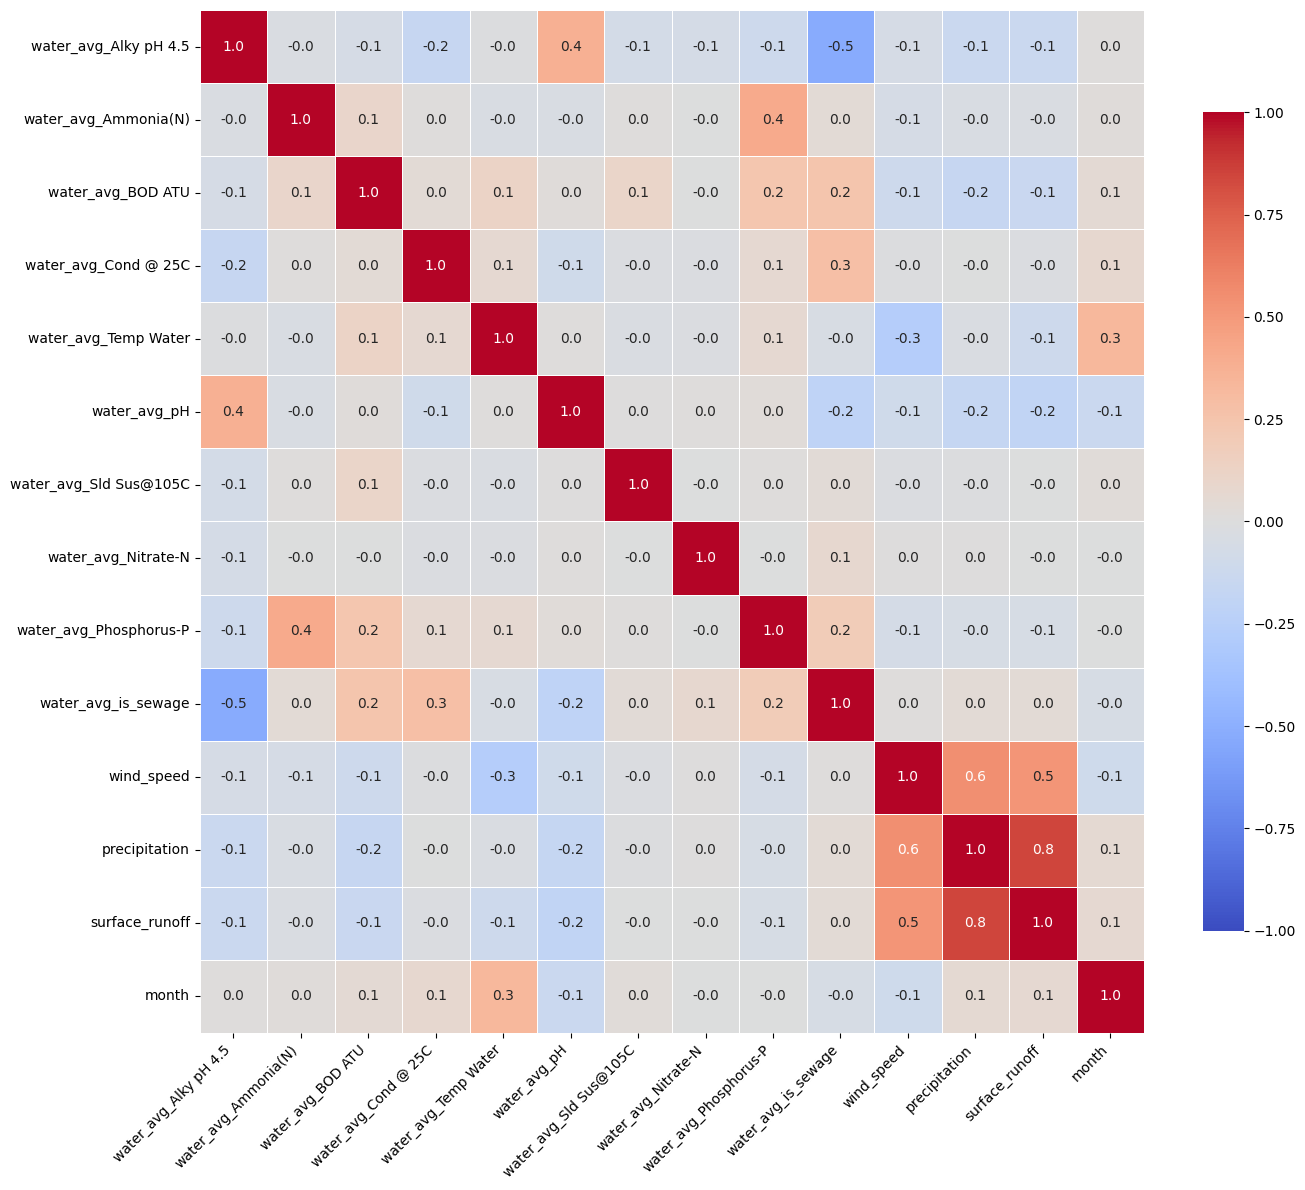

In [647]:
#correlation heatmap for numerical values
heatmapcols=['water_avg_Alky pH 4.5','water_avg_Ammonia(N)','water_avg_BOD ATU','water_avg_Cond @ 25C','water_avg_Temp Water','water_avg_pH','water_avg_Sld Sus@105C','water_avg_Nitrate-N','water_avg_Phosphorus-P','water_avg_is_sewage','wind_speed','precipitation','surface_runoff','month']
#just taking orginal column for corelating because others are duplicate data which is used to train the data in neural network
numeric_corr=merge_df[heatmapcols].select_dtypes(include=[np.number])
plt.figure(figsize=(14,12))
sns.heatmap(numeric_corr.corr(),annot=True,cmap='coolwarm',linewidths=0.5,fmt=".1f",cbar=True,vmax=1, vmin=-1,cbar_kws={"shrink": .8})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

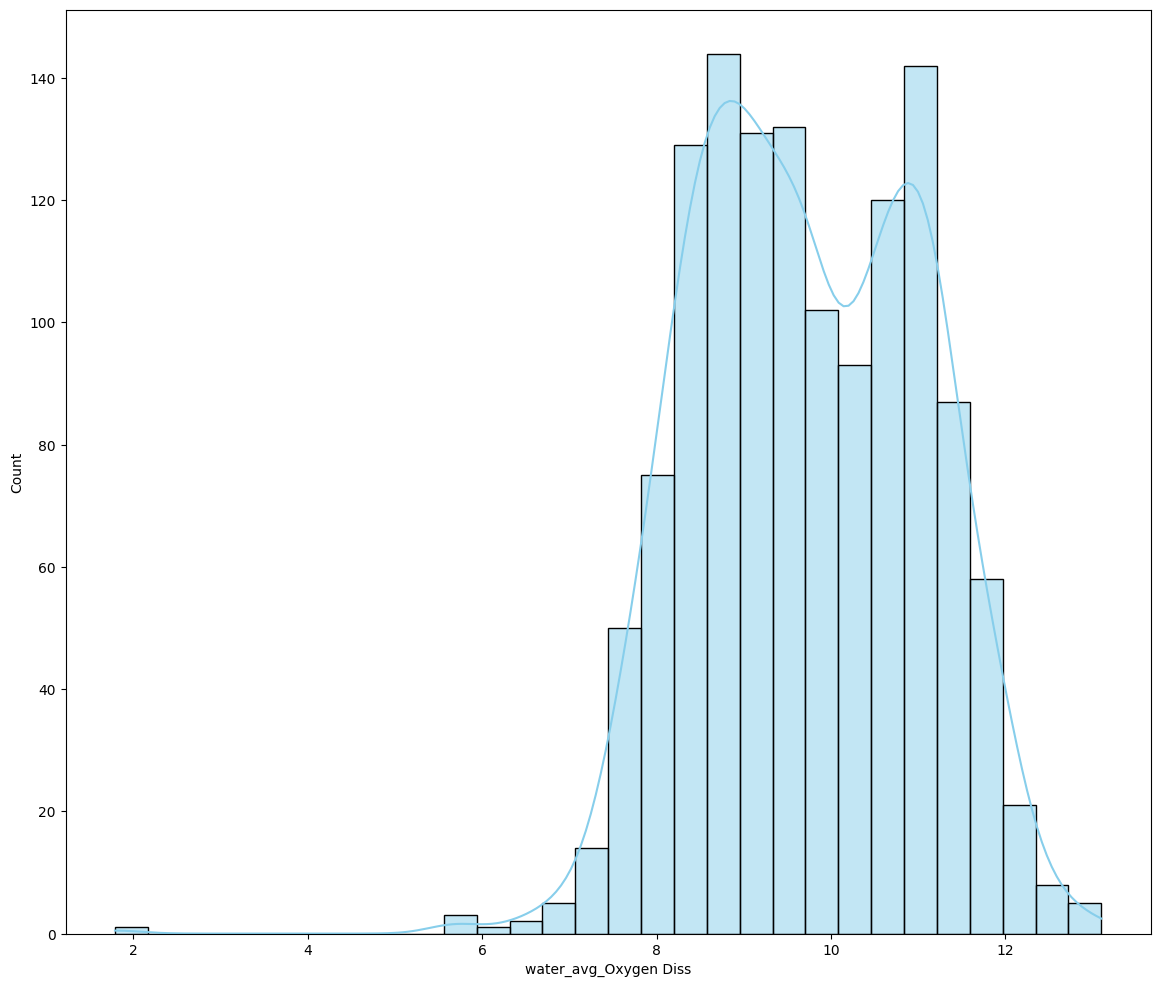

In [648]:
# Oxygen
plt.figure(figsize=(14,12))
sns.histplot(merge_df['water_avg_Oxygen Diss'], kde=True, color='skyblue')
plt.show()


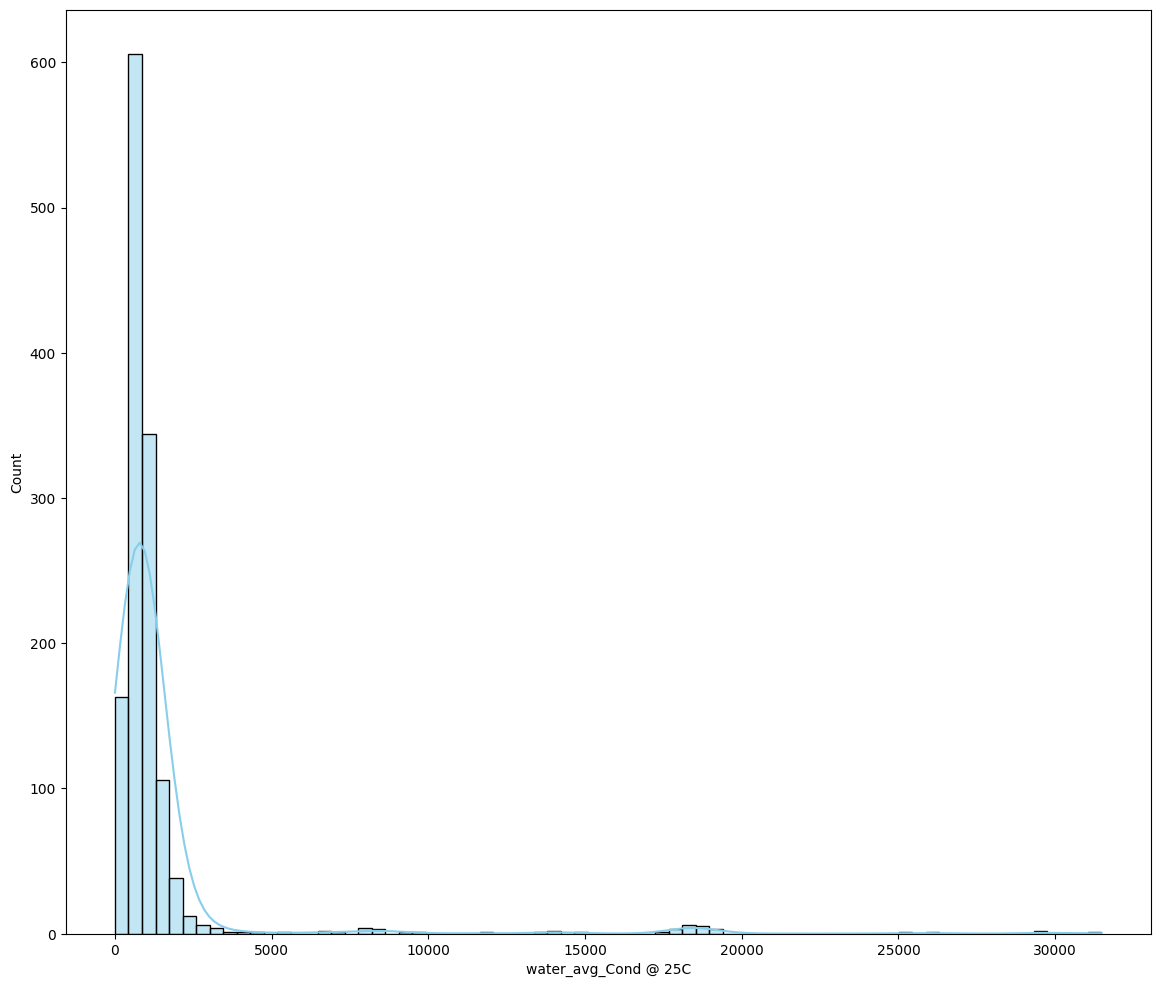

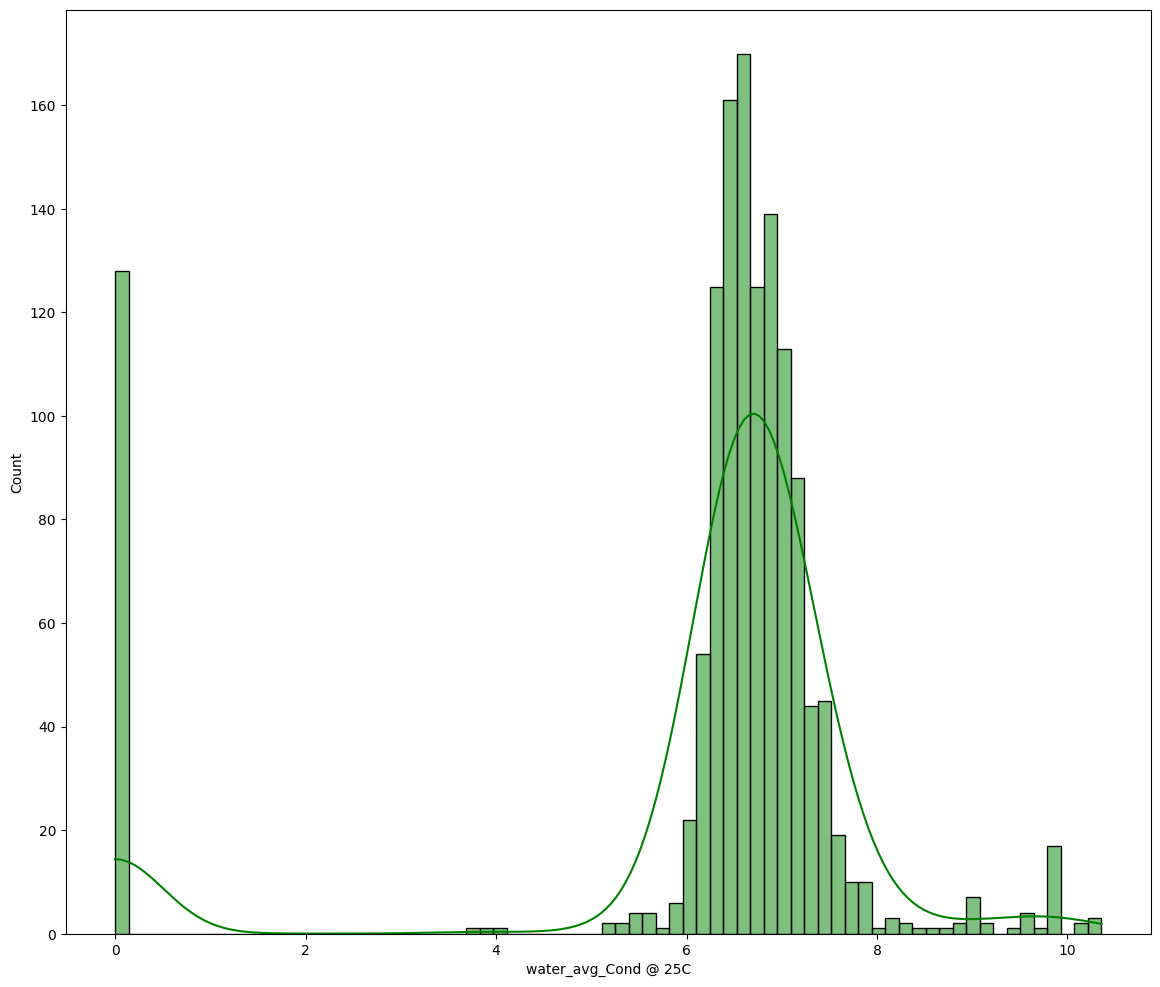

In [649]:
plt.figure(figsize=(14,12))
sns.histplot(merge_df['water_avg_Cond @ 25C'], kde=True, color='skyblue')

plt.show() 
plt.figure(figsize=(14,12))

sns.histplot(np.log1p(merge_df['water_avg_Cond @ 25C']), kde=True, color='green')
plt.show() 


In [650]:

merge_df['sin_month'] = np.sin(2 * np.pi * merge_df['month'] / 12)
merge_df['cos_month'] = np.cos(2 * np.pi * merge_df['month'] / 12)
#location
loc_encoder = LabelEncoder()
merge_df['loc_id'] = loc_encoder.fit_transform(merge_df['Target_Location'])
num_locations = len(loc_encoder.classes_)


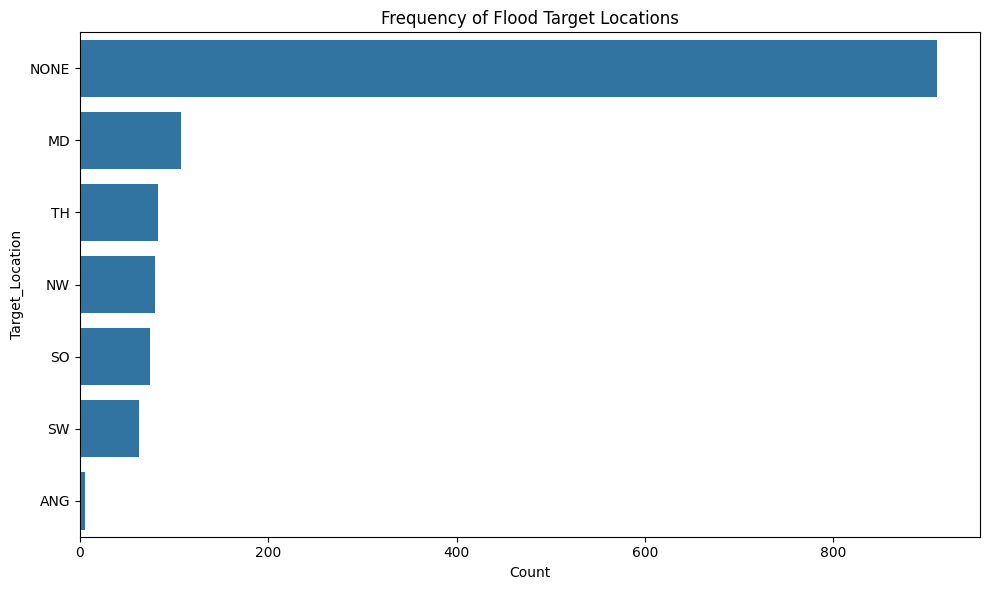

In [651]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Target_Location', data=merge_df, order=merge_df['Target_Location'].value_counts().index)
plt.title('Frequency of Flood Target Locations')
plt.xlabel('Count')
plt.tight_layout()



In [652]:

#Leaked cols ,why ? this is cause of data leakage why these elements in the water is highly correlated to  bacteria,so i'm excluding this data for training and also preventing from  overfitting 
leakage_cols = [
    'water_avg_Ammonia(N)',   
    'water_avg_COD as O2',    
    'water_avg_is_sewage',    
    'is_sewage',
    'loc_id',
    'Target_location'
    'water_avg_NH3 un-ion'
    'water_avg_pH'
]
#Predicting the variables
target_ox='water_avg_Oxygen Diss'
target_loc='Target_Location'
target_bod="water_avg_pH"
exclude_cols = [target_ox, target_bod, target_loc, 'only_date', 'date', 
                'sample.samplingPoint.notation', 'sample.samplingPoint.label'] + leakage_cols
#Features that shouldn't trained

features = [c for c in merge_df.columns if c not in exclude_cols and merge_df[c].dtype in ['float64', 'int64']]
#x variable
X = merge_df[features].values

In [653]:
#feed the neural network with scaling factor for the targeted prediction values
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
#targets to be predicted
#oxygen dissolved
scaler_y_ox = StandardScaler()
y_ox_log = np.log1p(merge_df['water_avg_Oxygen Diss'].values).reshape(-1, 1)
y_ox = scaler_y_ox.fit_transform(y_ox_log)
#BOD ATU
y_bod = np.log1p(merge_df['water_avg_pH'].values).reshape(-1, 1)

# 2. Then Scale
scaler_y_bod = StandardScaler()
y_bod_train = scaler_y_bod.fit_transform(y_bod)
#location
le = LabelEncoder()
# Make sure to encode the string labels to integers first
y_loc_int = le.fit_transform(merge_df['Target_Location'])
y_location = to_categorical(y_loc_int)
num_locations = y_location.shape[1]






In [654]:
X_train, X_test, y_ox_train, y_ox_test, y_bod_train, y_bod_test, y_loc_train, y_loc_test = train_test_split(X, y_ox, y_bod, y_location, test_size=0.2, random_state=42)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)


In [655]:
input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,), name='input_features')
class modelPrediction():
    def __init__(self,y_ox_train,y_ox_test,y_ni_train,y_ni_test,y_loc_train,y_loc_test,Y_loc):
        self.y_ox_train =y_ox_train
        self.y_ox_test=y_ox_test
        self.y_ni_train=y_ni_train
        self.y_ni_test=y_ni_test
        self.y_loc_train=y_loc_train
        self.y_loc_test=y_loc_test
        self.Y_loc=Y_loc
    def fnn(self):
        y_ox_train= self.y_ox_train
        y_ox_test= self.y_ox_test
        y_ni_train= self.y_ni_train
        y_ni_test=self.y_ni_test
        y_loc_train=self.y_loc_train
        y_loc_test=self.y_loc_test
        Y_loc=self.Y_loc
        #Tower for the biological patterns of oxygen dissolved
        t1 = Dense(128, activation='relu')(input_layer)
        t1 = BatchNormalization()(t1)
        t1 = Dropout(0.2)(t1)
        t1 = Dense(64, activation='relu')(t1)
        head_ox = Dense(1, activation='linear', name='out_ox')(t1)
        #Deeper and wider complicated towers for the harder task 
        t2 = Dense(256, activation='relu')(input_layer)
        t2 = BatchNormalization()(t2)
        t2 = Dropout(0.3)(t2)
        t2 = Dense(128, activation='relu')(t2)
        t2 = BatchNormalization()(t2)
        t2 = Dense(64, activation='relu')(t2)
        head_ni = Dense(1, activation='linear', name='out_ni')(t2)
        #Location neural tower for classification
        t3 = Dense(64, activation='relu')(input_layer)
        t3 = Dropout(0.2)(t3)
        n_classes = self.y_loc_train.shape[1]
        head_loc = Dense(n_classes, activation='softmax', name='out_loc')(t3)

        model = Model(inputs=input_layer, outputs=[head_ox, head_ni, head_loc])
        lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        model.compile(
            optimizer=Adam(learning_rate=0.002),
            loss={'out_ox': 'mse', 'out_ni': 'mse', 'out_loc': 'categorical_crossentropy'},
            loss_weights={'out_ox': 1.0, 'out_ni': 2.0, 'out_loc': 0.5} 
            )

        print("\n Independent training Model...")
        history=model.fit(
            X_train_scaled, [y_ox_train, y_ni_train, y_loc_train],
            epochs=100, batch_size=32, verbose=0,
            validation_data=(X_test_scaled, [y_ox_test, y_ni_test, y_loc_test]),
            callbacks=[lr_scheduler, early_stop]
        )

        #model Evaluate
        predictions = model.predict(X_test_scaled, verbose=0)
        
        # 1. Oxygen: Inverse Scale -> Then Expm1 (because it was log1p'd initially)
        real_ox_test = np.expm1(scaler_y_ox.inverse_transform(self.y_ox_test))
        real_ox_pred = np.expm1(scaler_y_ox.inverse_transform(predictions[0]))
        
        # 2. Conductivity: Inverse Scale ONLY (it was never log-transformed)
        real_ni_test = scaler_y_bod.inverse_transform(self.y_ni_test)
        real_ni_pred = scaler_y_bod.inverse_transform(predictions[1])

        # Scores
        r2_ox = r2_score(real_ox_test, real_ox_pred)
        r2_ni = r2_score(real_ni_test, real_ni_pred)
        acc_loc = accuracy_score(np.argmax(self.y_loc_test, axis=1), np.argmax(predictions[2], axis=1))
        
        print("\n--- Final Results (Corrected) ---")
        print(f"1. Oxygen Dissolved (R2): {r2_ox:.4f}")
        print(f"2. Conductivity (R2): {r2_ni:.4f}")
        print(f"3. Flood Location (Accuracy): {acc_loc:.4f}")
        
        y_true_loc = np.argmax(self.y_loc_test, axis=1)
        y_pred_loc = np.argmax(predictions[2], axis=1)
        
        return r2_ox,r2_ni,acc_loc,pd.DataFrame(history.history),y_true_loc,y_pred_loc,real_ox_test,real_ni_test,real_ox_pred,real_ni_pred
    def randomfm(self,X,merge_df):
        
        Y_con = merge_df['water_avg_pH'].values
        X_train_ni, X_test_ni, Y_train_ni, Y_test_ni = train_test_split(X, Y_con, test_size=0.2, random_state=42)
        rf_regressor_ni = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        rf_regressor_ni.fit(X_train_ni, Y_train_ni)
        Y_pred_ni = rf_regressor_ni.predict(X_test_ni)
        r2_ni = r2_score(Y_test_ni, Y_pred_ni)
        #average Miss
        rmse_ni = np.sqrt(mean_squared_error(Y_test_ni, Y_pred_ni))


        Y_ox = merge_df['water_avg_Oxygen Diss'].values
        X_train_ox, X_test_ox, Y_train_ox, Y_test_ox = train_test_split(X, Y_ox, test_size=0.2, random_state=42)
        rf_regressor_ox = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        rf_regressor_ox.fit(X_train_ox, Y_train_ox)
        Y_pred_ox = rf_regressor_ox.predict(X_test_ox)
        r2_ox = r2_score(Y_test_ox, Y_pred_ox)
        rmse_ox = np.sqrt(mean_squared_error(Y_test_ox, Y_pred_ox))


        Y_loc = merge_df['Target_Location'].values
        X_train_loc, X_test_loc, Y_train_loc, Y_test_loc = train_test_split(X, Y_loc, test_size=0.2, random_state=42)
        rf_classifier_loc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
        rf_classifier_loc.fit(X_train_loc, Y_train_loc)
        Y_pred_loc = rf_classifier_loc.predict(X_test_loc)  
        acc_loc = accuracy_score(Y_test_loc, Y_pred_loc)
        
        print("--- Random Forest Model Results ---")
        print(f"1. BOD ATU: {r2_ni:.4f}")
        print(f"1. BOD ATU: {rmse_ni:.4f}")
        print(f"2. Oxygen Dissolved (R2): {r2_ox:.4f}")
        print(f"2. Oxygen Dissolved (RMSE): {rmse_ox:.4f} mg/L")
        print(f"3. Flood Location (Accuracy): {acc_loc:.4f}")
        y_true_loc = Y_test_loc
        y_pred_loc = Y_pred_loc
        real_ox=Y_test_ox
        real_bod=Y_test_ni
        pred_ox=Y_pred_ox
        pred_bod=Y_pred_ni
        return r2_ox,r2_ni,acc_loc,y_true_loc,y_pred_loc,real_ox,real_bod,pred_ox,pred_bod


 Independent training Model...

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

--- Final Results (Corrected) ---
1. Oxygen Dissolved (R2): 0.7688
2. Conductivity (R2): -135.7985
3. Flood Location (Accuracy): 0.6981


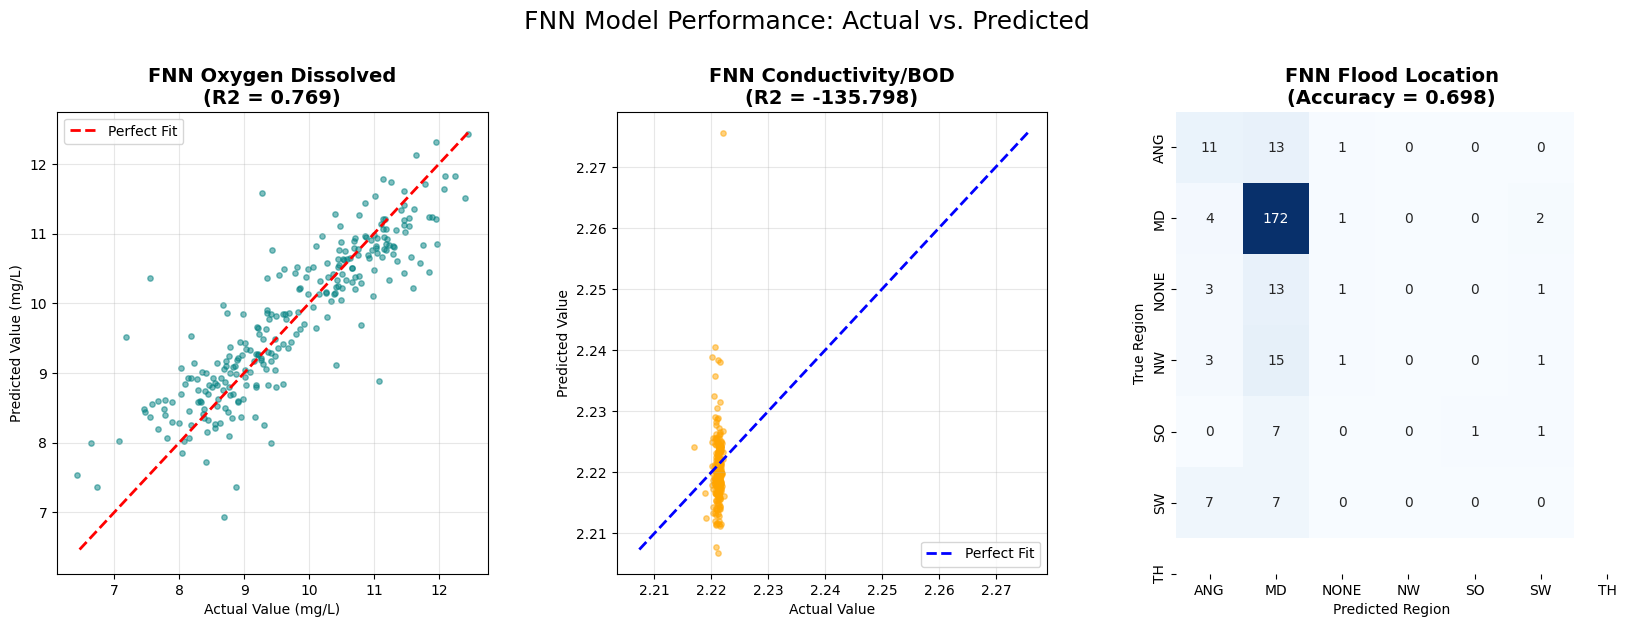

In [656]:
runModel= modelPrediction(y_ox_train,y_ox_test,y_bod_train,y_bod_test,y_loc_train,y_loc_test,y_location)
fnn_oxy,fnn_bod,fnn_location,fnn_history,location_true,prediction_location,real_ox,real_bod,pred_ox,predicted_bod=runModel.fnn()
ox_actual = real_ox
ox_pred = pred_ox
bod_actual = real_bod  
bod_pred = predicted_bod 
# Classification Data
loc_actual = location_true 
loc_pred = prediction_location 
target_names = [str(c) for c in le.classes_]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.3)

ax1 = axes[0]
ax1.scatter(ox_actual, ox_pred, alpha=0.5, color='teal', s=15)
p1 = max(max(ox_pred), max(ox_actual))
p2 = min(min(ox_pred), min(ox_actual))
ax1.plot([p1, p2], [p1, p2], 'r--', linewidth=2, label='Perfect Fit')
r2_ox = r2_score(ox_actual, ox_pred)
ax1.set_title(f"FNN Oxygen Dissolved\n(R2 = {r2_ox:.3f})", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Value (mg/L)")
ax1.set_ylabel("Predicted Value (mg/L)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
ax2.scatter(bod_actual, bod_pred, alpha=0.5, color='orange', s=15)
p1 = max(max(bod_pred), max(bod_actual))
p2 = min(min(bod_pred), min(bod_actual))
ax2.plot([p1, p2], [p1, p2], 'b--', linewidth=2, label='Perfect Fit')

r2_bod = r2_score(bod_actual, bod_pred)
ax2.set_title(f"FNN Conductivity/BOD\n(R2 = {r2_bod:.3f})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Actual Value")
ax2.set_ylabel("Predicted Value")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax3 = axes[2]
cm = confusion_matrix(loc_actual, loc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names, ax=ax3)

acc_loc = accuracy_score(loc_actual, loc_pred)
ax3.set_title(f"FNN Flood Location\n(Accuracy = {acc_loc:.3f})", fontsize=14, fontweight='bold')
ax3.set_xlabel("Predicted Region")
ax3.set_ylabel("True Region")

plt.suptitle("FNN Model Performance: Actual vs. Predicted", fontsize=18, y=1.05)
plt.show()

--- Random Forest Model Results ---
1. BOD ATU: 0.2402
1. BOD ATU: 0.1505
2. Oxygen Dissolved (R2): 0.8248
2. Oxygen Dissolved (RMSE): 0.5298 mg/L
3. Flood Location (Accuracy): 0.7057


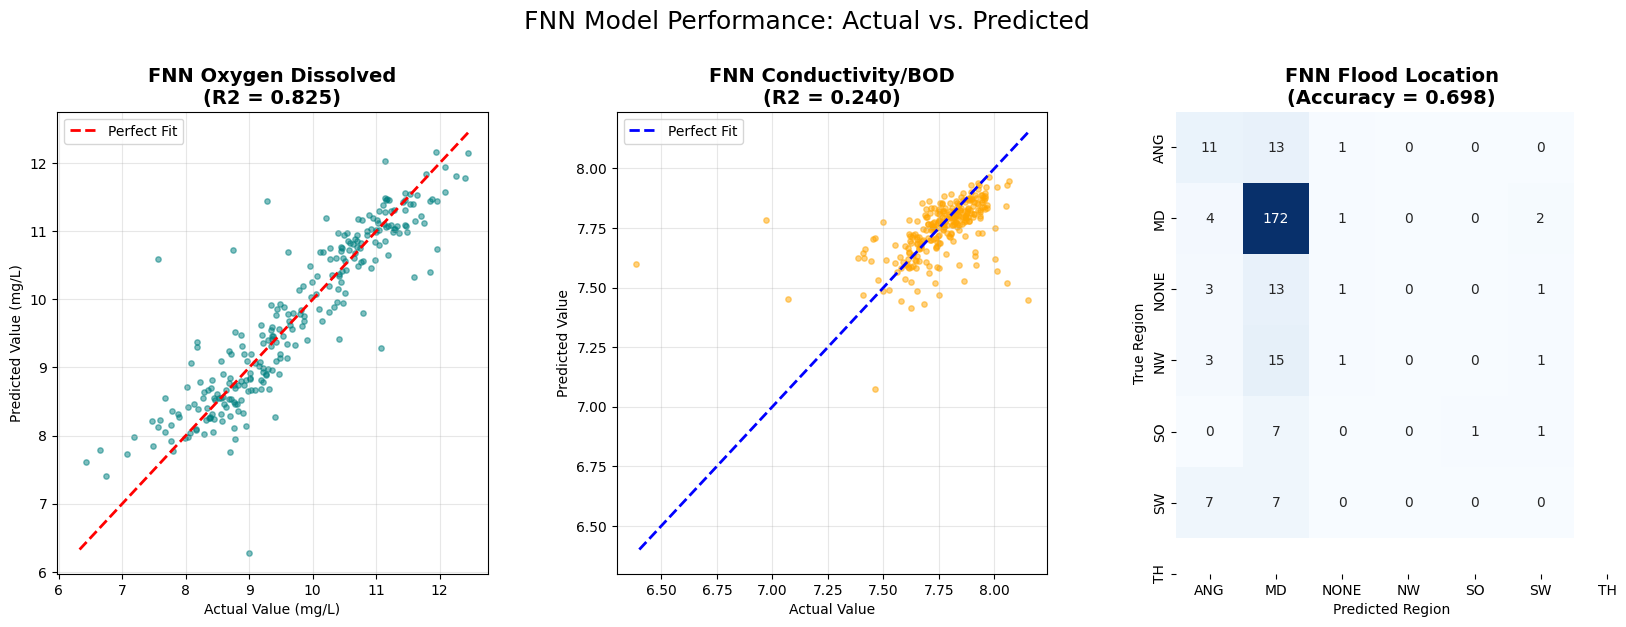

In [657]:
runModel= modelPrediction(y_ox_train,y_ox_test,y_bod_train,y_bod_test,y_loc_train,y_loc_test,y_location)
rf_oxy,rf_bod,rf_location,real_location,predicted_location,real_ox,real_bod,pred_ox,predicted_bod=runModel.randomfm(X,merge_df)
ox_actual = real_ox
ox_pred = pred_ox

bod_actual = real_bod 
bod_pred = predicted_bod
loc_actual = location_true
loc_pred = prediction_location 
target_names = [str(c) for c in le.classes_]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.3)
ax1 = axes[0]
ax1.scatter(ox_actual, ox_pred, alpha=0.5, color='teal', s=15)
p1 = max(max(ox_pred), max(ox_actual))
p2 = min(min(ox_pred), min(ox_actual))
ax1.plot([p1, p2], [p1, p2], 'r--', linewidth=2, label='Perfect Fit')

r2_ox = r2_score(ox_actual, ox_pred)
ax1.set_title(f"FNN Oxygen Dissolved\n(R2 = {r2_ox:.3f})", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Value (mg/L)")
ax1.set_ylabel("Predicted Value (mg/L)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
ax2.scatter(bod_actual, bod_pred, alpha=0.5, color='orange', s=15)
p1 = max(max(bod_pred), max(bod_actual))
p2 = min(min(bod_pred), min(bod_actual))
ax2.plot([p1, p2], [p1, p2], 'b--', linewidth=2, label='Perfect Fit')

r2_bod = r2_score(bod_actual, bod_pred)
ax2.set_title(f"FNN Conductivity/BOD\n(R2 = {r2_bod:.3f})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Actual Value")
ax2.set_ylabel("Predicted Value")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax3 = axes[2]
cm = confusion_matrix(loc_actual, loc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names, ax=ax3)

acc_loc = accuracy_score(loc_actual, loc_pred)
ax3.set_title(f"FNN Flood Location\n(Accuracy = {acc_loc:.3f})", fontsize=14, fontweight='bold')
ax3.set_xlabel("Predicted Region")
ax3.set_ylabel("True Region")

plt.suptitle("FNN Model Performance: Actual vs. Predicted", fontsize=18, y=1.05)
plt.show()

In [ ]:


y_loc_train_int = np.argmax(y_loc_train, axis=1)
y_loc_test_int = np.argmax(y_loc_test, axis=1)
classes = np.unique(y_loc_train_int)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_loc_train_int
)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[c] for c in y_loc_train_int])
print("Training XGBoost Models...")
model_ox = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)
model_ox.fit(X_train, y_ox_train)
model_bod = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=8,  # Deeper trees for complex pollution patterns
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)
model_bod.fit(X_train, y_bod_train)
model_loc = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softprob', 
    num_class=num_locations,
    n_jobs=-1,
    random_state=42
)

model_loc.fit(X_train, y_loc_train_int, sample_weight=sample_weights)
print("\nPredicting...")

# OXYgen predictions
pred_ox_scaled = model_ox.predict(X_test)
# Inverse Transform for oxygen
real_pred_ox = scaler_y_ox.inverse_transform(pred_ox_scaled.reshape(-1, 1))
real_y_ox = scaler_y_ox.inverse_transform(y_ox_test)


#BOD Predictions
pred_bod_scaled = model_bod.predict(X_test)
# Inverse BOD transformation
pred_bod_log = scaler_y_bod.inverse_transform(pred_bod_scaled.reshape(-1, 1))
real_y_bod_log = scaler_y_bod.inverse_transform(y_bod_test)
real_pred_bod = np.expm1(pred_bod_log)
real_y_bod = np.expm1(real_y_bod_log)

pred_loc_probs = model_loc.predict_proba(X_test)
pred_loc_classes = np.argmax(pred_loc_probs, axis=1)

xg_oxygen=r2_score(real_y_ox, real_pred_ox)
xg_bod=r2_score(real_y_bod, real_pred_bod)
xg_flood=accuracy_score(y_loc_test_int, pred_loc_classes)
print("\nXGBoost Final Results ")
print(f"Oxygen Dissolved R2: {xg_oxygen:.2f}")
print(f"BOD ATU (Pollution) R2: {xg_bod:.2f}")
print(f"Flood Location Accuracy: {xg_flood:.2f}")

Training XGBoost Models...

Predicting...

--- XGBoost Final Results ---
Oxygen Dissolved R2: 0.71
BOD ATU (Pollution) R2: -0.43
Flood Location Accuracy: 0.71


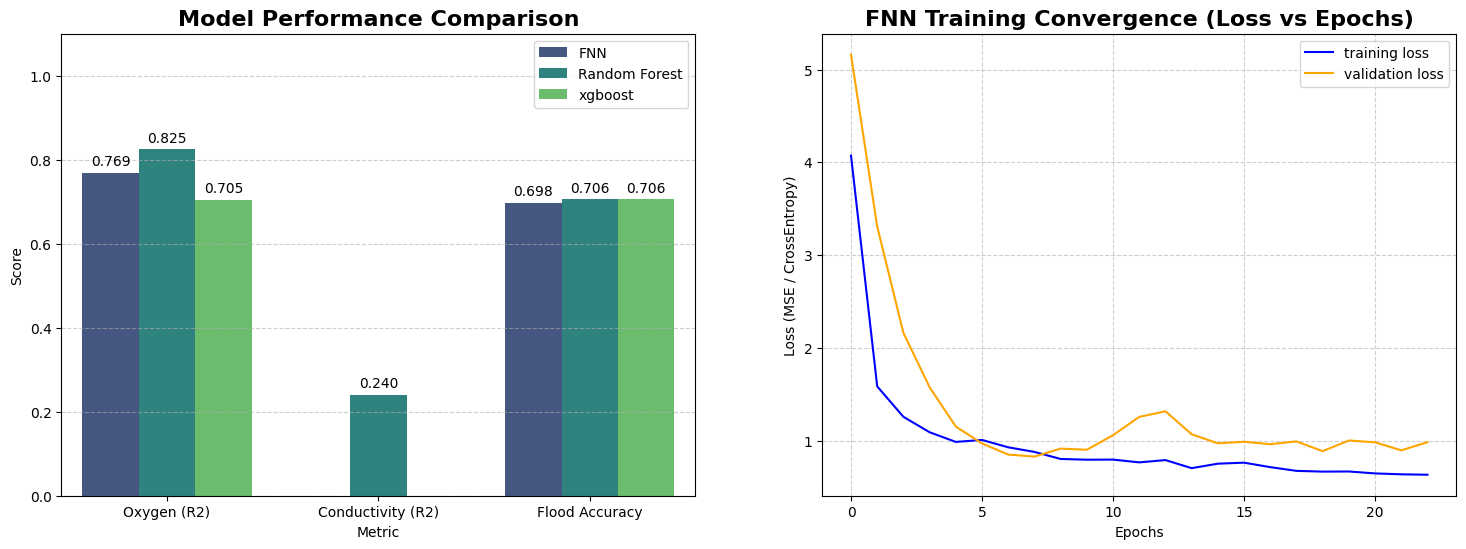

In [ ]:
from cProfile import label
from turtle import color
data = {
    'Metric': ['Oxygen (R2)', 'Oxygen (R2)','Oxygen (R2)', 'Conductivity (R2)', 'Conductivity (R2)','Conductivity (R2)', 'Flood Accuracy', 'Flood Accuracy','Flood Accuracy'],
    'Model': ['FNN', 'Random Forest','xgboost' ,'FNN', 'Random Forest', 'xgboost','FNN', 'Random Forest','xgboost'],
    'Score': [fnn_oxy, rf_oxy,xg_oxygen, fnn_bod, rf_bod, xg_bod,fnn_location, rf_location,xg_flood]
}
df_compare = pd.DataFrame(data)
df_compare.head()
fig = plt.figure(figsize=(18, 6))


ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df_compare, x='Metric', y='Score', hue='Model', palette='viridis', ax=ax1)

ax1.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', padding=3)
ax2 = plt.subplot(1, 2, 2)
ax2.plot(fnn_history['loss'],label='training loss',color='blue')
ax2.plot(fnn_history['val_loss'],label='validation loss',color='orange')
ax2.set_title('FNN Training Convergence (Loss vs Epochs)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss (MSE / CrossEntropy)')
ax2.legend() 
ax2.grid(True, linestyle='--', alpha=0.6)
plt.show()  